# Train model 1

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPT-2's tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/Users/shre/courses/llm_deep_dive/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# use the GPU for speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Hyperparameters

In [4]:
# data hyperparameters
seq_len = 8 # context length
stride = 2

# model hyperparameters
embed_dim = 2**6 # 64

# training hyperparameters
batch_size = 64

## Get data

In [5]:
# tokenize the text and make it a tensor
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

Token indices sequence length is longer than the specified maximum sequence length for this model (48533 > 1024). Running this sequence through the model will result in indexing errors


48533

## DataLoader

In [6]:
# create a class for a dataset (note: batching is done by the DataLoader, not in the dataset)
class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len=8, stride=4) -> None:
        # initialize
        self.inputs = []
        self.targets = []

        # overlapping sequences of seq_len
        for i in range(0, len(tokens)-seq_len, stride):
            # get c tokens and append to lists
            self.inputs.append(tokens[i: i+seq_len])
            self.targets.append(tokens[i+1 : i+1+seq_len])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

In [7]:
# create an instance
token_dataset = TokenDataset(tmTokens, seq_len, stride)
token_dataloader = DataLoader(token_dataset, batch_size=batch_size, shuffle=True)
next(iter(token_dataloader))

[tensor([[36001,   407,    13,   447,   251,   201,   198,   201],
         [18598,  1231,  2252,  7030,   286,   201,   198,  2435],
         [  766,   201,   198,  9579,   340,   262,  3461, 28860],
         [  198, 35782,    12,  7038,    13,   383,  5253,    11],
         [  607,   379,   938,    11, 19064,   290,   201,   198],
         [14146,  3589,   287,    11,   314,  1043,   340,   373],
         [  257,  1178,  1528,   262,  8824,  1276,  1208,   832],
         [ 5391, 16187,   201,   198,  1659,  7777,    11,   262],
         [36198,  3436,    13,   887,   772,   981,   314,   201],
         [  407,   760,   703,   890,   314,  3830,    13,   314],
         [  981,  2111,   287,   511,  5391,   835,   284,   201],
         [  564,   250,  4360,   345,   481,   201,   198, 12081],
         [  201,   198, 13424, 30485,   286,   262, 40671,  7150],
         [  367,  3087,   494, 14179,    13,   383,   201,   198],
         [  284,   201,   198, 47350,   284,   502,    11,   4

## The model

In [8]:
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        # embedding matrix
        self.embedding = nn.Embedding(tokenizer.vocab_size, embed_dim)

        # embedding to output layer
        self.gelu = nn.GELU()
        self.finalLinear = nn.Linear(embed_dim, tokenizer.vocab_size)
    
    def forward(self, tokx):
        # forward pass
        x = self.embedding(tokx) # [batch, token, embeddings]
        x = self.gelu(x)
        x = self.finalLinear(x) # [embeddings, vocab]

        # return lof-softmax
        return F.log_softmax(x,dim=-1)
    
    def generate(self, tokx, n_new_tokens = 30):
        for _ in range(n_new_tokens):
            x = self(tokx)
            x = x[:, -1, :]
            probs = torch.exp(x) # undo the log but keep the softmax
            nextToken = torch.multinomial(probs, num_samples=1)
            tokx = torch.cat( (tokx,nextToken),dim=1)
        
        return tokx

## check model output

In [9]:
model = Model()
X,y = token_dataset[4]
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape) # confirm torch.sum(torch.exp(out))==1

torch.Size([8])
torch.Size([8])
torch.Size([8, 50257])


In [11]:
torch.sum(torch.exp(out))

tensor(8.0000, grad_fn=<SumBackward0>)

In [12]:
print(X)
print(y)
print(torch.argmax(out))

tensor([ 1677, 13246,    38,   412, 39453,  3439, 17202,   201])
tensor([13246,    38,   412, 39453,  3439, 17202,   201,   198])
tensor(293177)


## Prepare for training

In [13]:
# push the model to the GPU
model = model.to(device)

In [14]:
# create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

In [15]:
# check loss function with sizes
X, y = next(iter(token_dataloader))
log_probs = model(X.to(device))

print(f'Model input is size:   {X.shape}')
print(f'Model output is size:  {log_probs.shape}')
print(f'Target tokens is size: {y.shape}')

# uh oh...
loss_function(log_probs[:,:-1,:],y[:,1:].to(device))

Model input is size:   torch.Size([64, 8])
Model output is size:  torch.Size([64, 8, 50257])
Target tokens is size: torch.Size([64, 8])


RuntimeError: Expected target size [64, 50257], got [64, 7]

In [16]:
# flatten to [batch*token, vocab]
log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1])

# flaatten to a vector
y_flat = y[:, 1:].reshape(-1)

print(f'Model output is size:  {log_probs_flat.shape}')
print(f'Target tokens is size: {y_flat.shape}')

# Now compute the loss
loss = loss_function(log_probs_flat, y_flat.to(device))
print('\nLoss:',loss)

Model output is size:  torch.Size([448, 50257])
Target tokens is size: torch.Size([448])

Loss: tensor(10.9267, grad_fn=<NllLossBackward0>)


In [17]:
# some model generated text (compare with post-training)

# needs to be a tensor with one batch
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device))
print(tokenizer.decode(Y[0].tolist()))

I thought the Eloi would be smarter than cynical bagcture allegiance averagedolars SPI bestselling Survive expectations unheard Gibson reset staggered ZhHar Fellqqa ManilaLa Coach ped pe fue prag adulthood savioralong grand 251


## Now train the model!

In [18]:
num_epochs = 25

# initialize losses
total_loss = np.zeros(num_epochs)

# training loop 
for epoch in range(num_epochs):
    # initialize batch losses to accumulate
    epoch_loss = 0

    # loop over batches in the data loader
    for X, y in token_dataloader:
        # move data to GPU
        X, y = X.to(device), y.to(device)

        # clear previous gradients
        model.zero_grad()

        # forward pass
        log_probs = model(X)

        # calculate the losses on the (reshaped) final target word
        log_probs_flat = log_probs[:, :-1, :].reshape(-1, log_probs.shape[-1]) # tokens 0:N-1
        y_flat = y[:, 1:].reshape(-1) # tokens 1:N
        loss = loss_function(log_probs_flat, y_flat)

        # backprop
        loss.backward()
        optimizer.step()

        # sum the batch loss
        epoch_loss += loss.item()
    
    # scale by the number of tokens in this dataloader
    total_loss[epoch] = epoch_loss / len(token_dataloader)

    # update our progress
    if epoch%2 == 0:
        print(f'Finished epoch {epoch+1:2} with loss {epoch_loss / len(token_dataloader):.4f}')

Finished epoch  1 with loss 7.4413
Finished epoch  3 with loss 5.2413
Finished epoch  5 with loss 4.8231
Finished epoch  7 with loss 4.5539
Finished epoch  9 with loss 4.3613
Finished epoch 11 with loss 4.2096
Finished epoch 13 with loss 4.0874
Finished epoch 15 with loss 3.9841
Finished epoch 17 with loss 3.8977
Finished epoch 19 with loss 3.8289
Finished epoch 21 with loss 3.7746
Finished epoch 23 with loss 3.7296
Finished epoch 25 with loss 3.6932


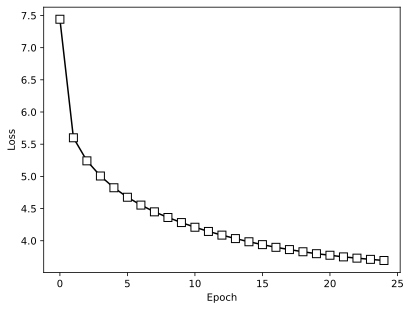

In [19]:
# plot the losses
plt.plot(total_loss,'ks-',markerfacecolor='w',markersize=8)
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

In [20]:
# theoretical loss for untrained weights
-np.log(1/tokenizer.vocab_size)

np.float64(10.82490511970208)

In [21]:
# check the model output for a training sequence
print(tokenizer.decode(X[6].tolist()))
print(tokenizer.decode(y[6].tolist()))

 When I had started with the Time Machine
 I had started with the Time Machine,


In [26]:
# and generate new topic-related data

# needs to be a tensor with one batch
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device),n_new_tokens=80)
print(tokenizer.decode(Y[0].tolist()))

d very little, face flushed animated andsities impressed thealravings I that following. breeze in wh andism of wood
 think this
icked. were from corro and
one the, I it
 the effect my from pocket interest here there a or language excessively.�ions in circle the,


In [27]:
# when the initial text doesn't repeat:
startToks,Y

(tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621]]),
 tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621,   318,
            887,   201,   201,   464,   286,  1509,   201, 18392,   290,  7498,
            770,   287,  3223,   290, 41918, 12617,   262,   282, 42335,   314,
            326,  1708,    13, 28633,   287,   348,   290,  1042,   286,  4898,
            201,    67,   845,  1310,    11,  1986, 44869, 15108,   290,   198,
            892,   428,   198,  9484,    13,   547,   422, 26132,   290,   198,
          35753,   651,    11,   340,   201,   505,   262,    11,   314,   198,
            262,  1245,   616,   422, 10000,  1393,   994,   612,   257,   393,
           3303, 40437,    13,   246,   507,   287,  9197,   262,    11]]))

In [28]:
# use this:
print(tokenizer.decode(Y[0].tolist()).replace('\r','\n'))

I thought the Eloi would be smarter than is But

The of sw
engine and marked This in dark and necessities impressed thealravings I that following. breeze in wh andism of wood
d very little, face flushed animated and
 think this
icked. were from corro and
xiety get, it
one the, I
 the effect my from pocket interest here there a or language excessively.�ions in circle the,


In [29]:
# b/c of the carriage return (go to the beginning of the line, not the next line)
tokenizer.decode([201])

'\r'